# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [1]:
!pip install mat73 h5py
!pip install pandas matplotlib scipy



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    './archive'
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : ./archive
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [4]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 47
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 5_2C_58PER_4C
  policy_readable           | str      | 5.2C(58%)-4C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [7]:
cell = batch[0]
print(cell['barcode'])
print(cell['Vdlin'][:5])  # 앞 5개 값
print(len(cell['Vdlin'])) # 몇 개 포인트?

None
[3.5        3.4984985  3.496997   3.4954955  3.49399399]
1000


In [8]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 496

사이클[0] 내 변수 목록 :
  I               | ndarray | shape=(1042,) | dtype=float64
  Qc              | ndarray | shape=(1042,) | dtype=float64
  Qd              | ndarray | shape=(1042,) | dtype=float64
  Qdlin           | ndarray | shape=(1000,) | dtype=float64
  T               | ndarray | shape=(1042,) | dtype=float64
  Tdlin           | ndarray | shape=(1000,) | dtype=float64
  V               | ndarray | shape=(1042,) | dtype=float64
  discharge_dQdV  | ndarray | shape=(1000,) | dtype=float64
  t               | ndarray | shape=(1042,) | dtype=float64


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [15]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)
        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [12]:
nan_count = sum(1 for cell in batch if np.isnan(float(cell['cycle_life'])))
print(f"cycle_life NaN : {nan_count} / {len(batch)}")


cycle_life NaN : 8 / 47


In [16]:
valid_batch = [cell for cell in batch if not np.isnan(float(cell['cycle_life']))]
print(f"유효 셀 : {len(valid_batch)} / {len(batch)}")

df = extract_summary(valid_batch)
print(f"DataFrame shape : {df.shape}")
df.head()


유효 셀 : 39 / 47
DataFrame shape : (23034, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,477,5.2C(58%)-4C,1.100081,1.093134,0.017568,34.939963,31.711117,29.923351,10.173582
1,0,2,477,5.2C(58%)-4C,1.102005,1.095290,0.017403,34.932640,31.694268,29.485325,10.174120
2,0,3,477,5.2C(58%)-4C,1.102657,1.095671,0.017483,35.013324,31.562588,29.496650,10.173655
3,0,4,477,5.2C(58%)-4C,1.104077,1.096824,0.017495,34.874825,31.466974,29.558488,10.173165
4,0,5,477,5.2C(58%)-4C,1.103926,1.095358,0.017292,34.603157,31.418444,29.035449,10.174460


In [ ]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

In [18]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000,23034.000
mean,20.593,339.595,650.175,1.050,1.048,0.014,37.051,33.316,30.725,12.609
std,11.726,252.311,265.142,0.067,0.059,0.007,2.562,1.455,1.320,81.758
min,0.000,1.000,392.000,0.825,0.829,0.000,29.528,29.054,0.000,10.015
25%,9.000,148.000,449.000,1.030,1.027,0.015,35.106,32.328,30.236,10.051
50%,22.000,296.000,491.000,1.076,1.065,0.017,37.105,33.292,30.629,10.175
75%,31.000,447.000,841.000,1.097,1.085,0.017,38.963,34.068,31.164,10.366
max,38.000,1252.000,1186.000,1.121,1.174,0.023,42.950,38.872,34.871,3934.705


In [19]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [20]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")
print(f"ct 종류 : {df['chargetime'].nunique()}")


배터리 셀 수   : 39
충전 정책 종류 : 12
ct 종류 : 20046


## EDA(Basic)

### 1. Cycle Life 분포

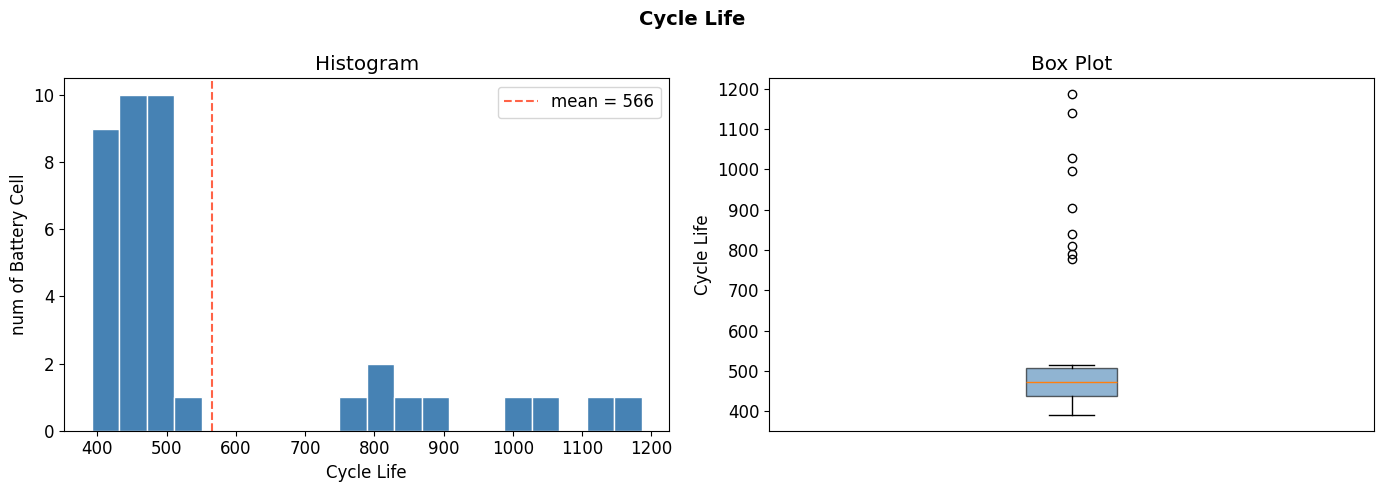

count      39.0
mean      565.7
std       222.2
min       392.0
25%       439.5
50%       472.0
75%       508.5
max      1186.0
Name: cycle_life, dtype: float64


In [21]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

In [23]:
cycle_life_df = df.drop_duplicates('cell_id')['cycle_life']

under_500 = (cycle_life_df < 500).sum() / len(cycle_life_df) * 100
over_1000 = (cycle_life_df > 1000).sum() / len(cycle_life_df) * 100

print(f"500 미만  : {under_500:.1f}%  ({(cycle_life_df < 500).sum()}개)")
print(f"1000 초과 : {over_1000:.1f}%  ({(cycle_life_df > 1000).sum()}개)")


500 미만  : 71.8%  (28개)
1000 초과 : 7.7%  (3개)


### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

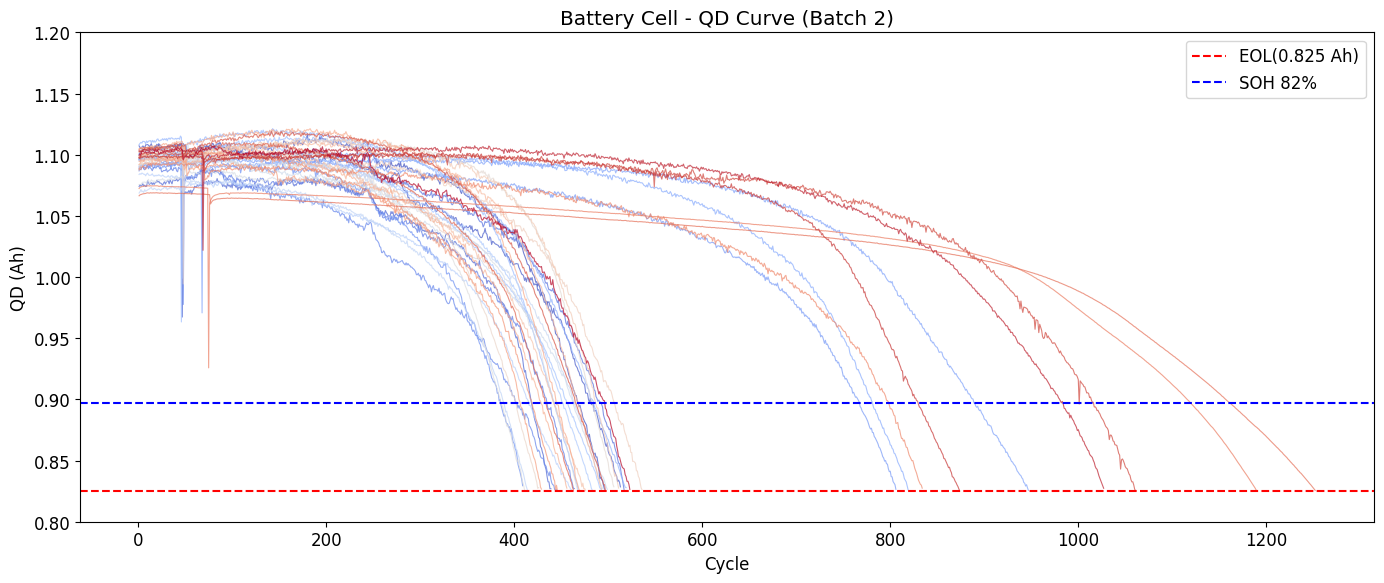

In [36]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=nominal * 0.754, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.754:.3f} Ah)')
ax.axhline(y=0.82 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='blue', linestyle='--', linewidth=1.5, label='SOH 82%')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Batch 2)')
ax.set_ylim(0.8, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
initial_qd = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median()
df['SoH'] = df['QD'] / df['cell_id'].map(initial_qd) * 100

last_cycle = df.loc[df.groupby('cell_id')['cycle'].idxmax(),
                    ['cell_id', 'cycle', 'cycle_life', 'charging_policy', 'QD', 'SoH']]
print(last_cycle.to_string())
print(f"\nSoH 평균 : {last_cycle['SoH'].mean():.1f}%")
print(f"SoH 범위 : {last_cycle['SoH'].min():.1f}% ~ {last_cycle['SoH'].max():.1f}%")


       cell_id  cycle  cycle_life              charging_policy        QD        SoH
495          0    496         477                 5.2C(58%)-4C  0.826613  74.965594
1008         1    513         491               5.6C(26%)-4.5C  0.828482  74.900043
1447         2    439         424              5.2C(50%)-4.25C  0.827009  76.942809
1964         3    517         499                4.65C(44%)-5C  0.825510  75.307424
2428         4    464         444                4.65C(69%)-6C  0.827127  75.913357
2873         5    445         416                 3.6C(30%)-6C  0.826154  75.180301
3282         6    409         393                  3.6C(9%)-5C  0.829404  76.192616
4088         7    806         777  4.8C(80%)-4.8C-newstructure  0.826481  75.762829
5035         8    947         904    5.2C(58%)-4C-newstructure  0.825586  75.697428
5854         9    819         791  5.6C(26%)-4.5C-newstructure  0.826105  75.293853
6373        10    519         492               4.8C(80%)-4.8C  0.827911  74

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0962 Ah
필터 범위          : 0.8769 ~ 1.3154 Ah
제거된 행 수       : 944 (4.10%)


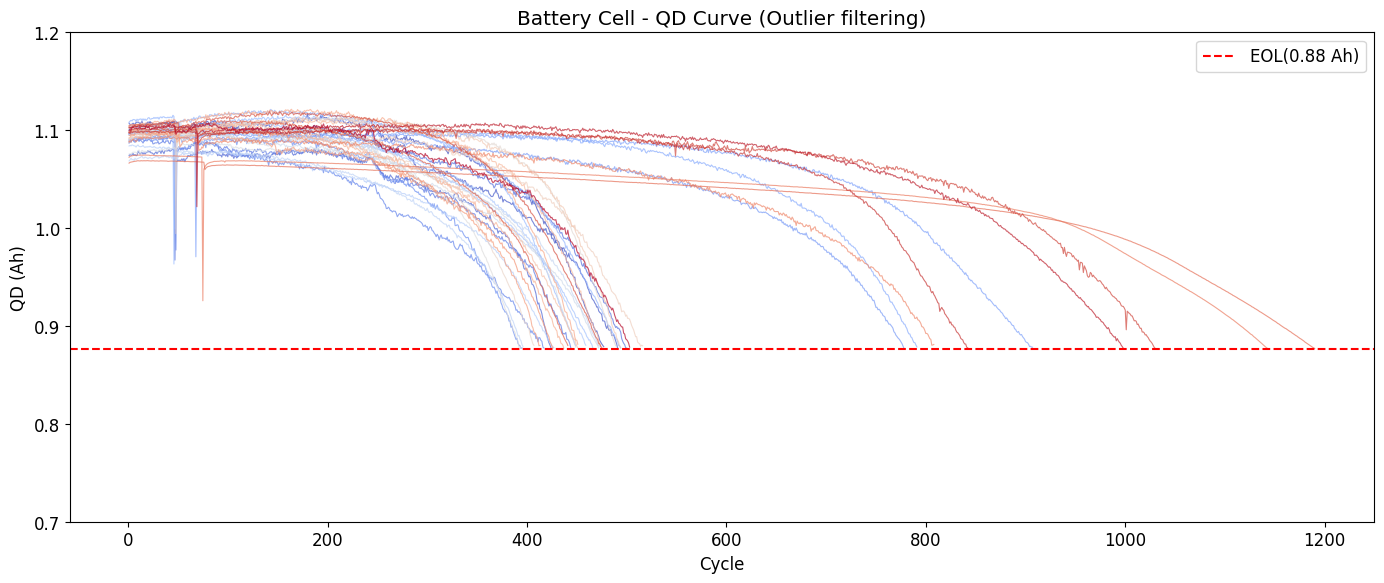

In [37]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 달느 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

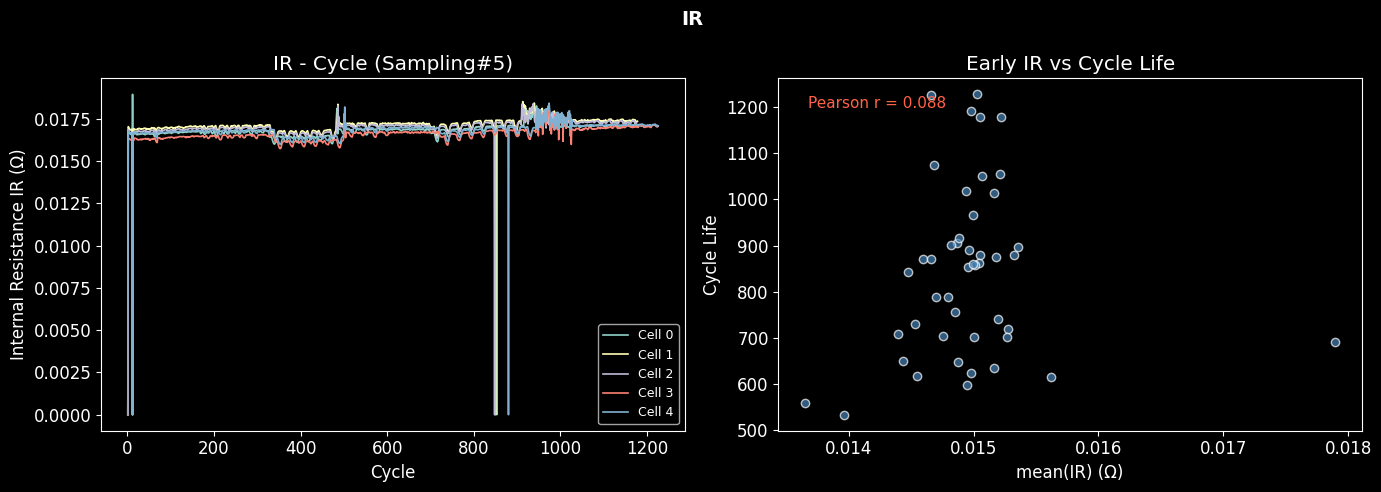

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

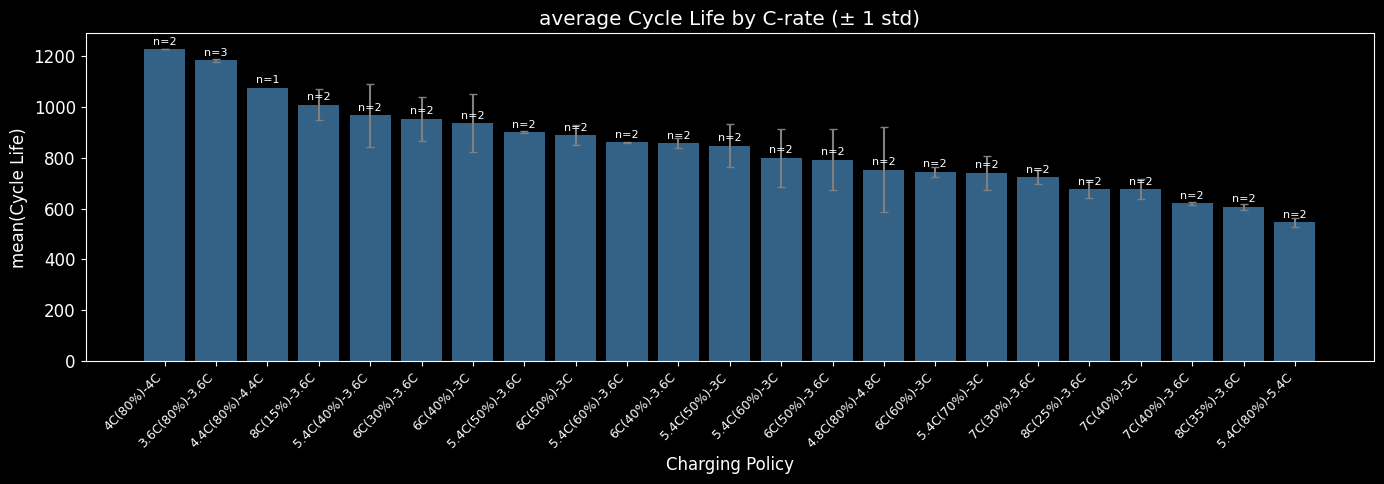

In [29]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

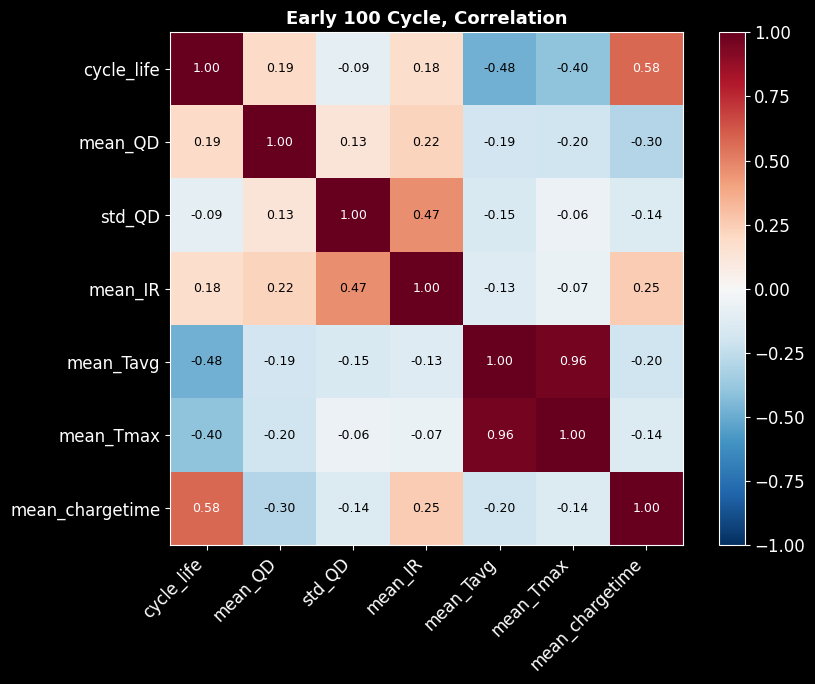


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [30]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.